# GHS-POP Population Grids

People counted onto a regular grid, from the Global Human Settlement Layer at the European
Commission's Joint Research Centre. The climate and economic sources here arrive as tables keyed by
country and year. This one is a raster, and it is what puts a population under a model that works in
space rather than by country.

## Provenance

These are the fields of the declaration `population_source` builds in `climate_risk/data/ghsl.py`.
One epoch is one file, so the URL and filename carry the year and the rest is shared across the
release.

In [1]:
import dataclasses

from IPython.display import Markdown

from climate_risk.data.ghsl import population_source

declared = {"publisher": "European Commission, Joint Research Centre"} | dataclasses.asdict(population_source(2020))
rows = [f"| {field} | {value} |" for field, value in declared.items()]

Markdown("\n".join(["| Field | Value |", "|---|---|", *rows]))

| Field | Value |
|---|---|
| publisher | European Commission, Joint Research Centre |
| url | https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_POP_GLOBE_R2023A/GHS_POP_E2020_GLOBE_R2023A_4326_30ss/V1-0/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.zip |
| filename | GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.zip |
| license | European Commission reuse notice: reuse authorised provided the source is acknowledged |
| citation | Schiavina, M., Freire, S., Carioli, A., MacManus, K. (2026): GHS-POP R2023A - GHS population grid multitemporal (1975-2030). European Commission, Joint Research Center. doi:10.2905/2FF68A52-5B5B-4A22-8F40-C41DA8332CFE |
| retrieved | 2026-08-23 |

## Loading it

Counting people takes a grid to count them onto, so this runs in three steps rather than one call.
A boundary is cut out of the world shapefile, a lattice is laid over it, and the raster is reduced
onto the cells. A cold run fetches the world shapefile as well as the 450 MB population archive.
The cache directory is your choice, and this page uses one named `data` in the working directory.

In [2]:
import logging

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.colors import LogNorm

import climate_risk as cr

from climate_risk.data.ghsl import POPULATION_EPOCHS, population_on_cells
from climate_risk.geo.raster import build_cell_grid, dissolve_place_boundary
from climate_risk.plotting import PALETTE, configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [3]:
cache_dir = Path("data")
COUNTRY = "VNM"
EPOCH = 2020

# The world shapefile already carries ISO_A3, so the country is selected before dissolving. The
# `iso3` argument labels a geometry that has no code of its own and does not filter one that does.
world = cr.load_shapefile("world", cache_dir)
boundary = dissolve_place_boundary(world.query("ISO_A3 == @COUNTRY"))

In [4]:
grid = build_cell_grid(boundary, resolution_km=25.0)

In [5]:
people = population_on_cells(grid, EPOCH, cache_dir)

## What you get

A plain NumPy array, one value per cell, in the order of `grid.cells`. It carries no index of its
own, so it means nothing apart from the grid it was sampled onto. Attaching it to that frame is what
makes it readable.

In [6]:
per_cell = grid.cells.assign(people=people)
per_cell[["cell_id", "lon", "lat", "cell_area_km2", "place_area_km2", "people"]].head()

,cell_id,lon,lat,cell_area_km2,place_area_km2,people
0,11,104.85,23.25,602.87,24.30,2676.83
1,12,105.08,23.25,602.87,242.43,44453.55
2,13,105.32,23.25,602.87,450.05,75245.32
3,14,105.56,23.25,602.87,52.74,7782.72
4,42,104.85,23.03,603.85,362.78,40889.31


## Units

| Column | Unit |
|---|---|
| `cell_id` | position in the full lattice, north row first |
| `lon`, `lat` | cell center, degrees in EPSG:4326 |
| `cell_area_km2` | square kilometers of the whole cell |
| `place_area_km2` | square kilometers of the cell inside the country |
| `people` | people, counted over `place_area_km2` |

The raster band is people per raster cell, and `population_on_cells` sums it, because a headcount is
extensive. An intensive quantity such as an elevation would take a mean instead. The sum runs over
each cell's intersection with the country, so a cell on the border is credited only with the people
inside it.

## Coverage

The release publishes twelve epochs on one grid, five years apart, which is what lets a population
be interpolated to a panel year. They all share a shape, so an operator built against one reads any
of them.

In [7]:
pd.DataFrame(
    {
        "epochs": [len(POPULATION_EPOCHS)],
        "first": [POPULATION_EPOCHS[0]],
        "last": [POPULATION_EPOCHS[-1]],
        "lattice": [f"{grid.shape[0]} by {grid.shape[1]}"],
        "cells in the country": [len(grid.cells)],
        "people": [f"{people.sum():,.0f}"],
    }
)

,epochs,first,last,lattice,cells in the country,people
0,12,1975,2030,66 by 31,689,"94,840,478"


In [8]:
per_cell["people"].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
people,689.00,137649.46,353029.75,0.00,10910.19,45549.61,134677.71,4880817.05


## A plot

Vietnam at 25 km, as people per square kilometer rather than the raw count the loader returns. The
count is what a model wants, but a cell clipped to a sliver of coast holds few people because it
holds little land, and on a map that reads as empty ground. Dividing by the land inside each cell
makes the cells comparable. The Red River delta and the Mekong delta are the two bright regions, and
the dark spine between them is the Annamite range.

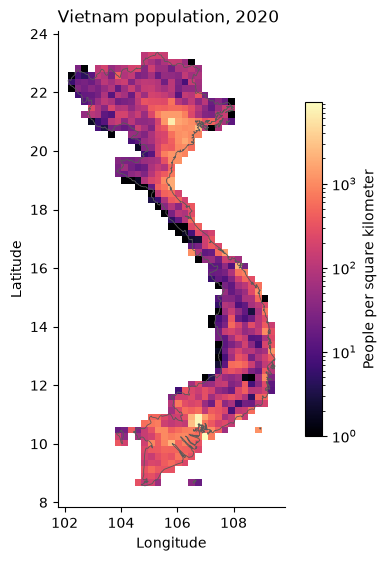

In [9]:
# grid.cells carries cell centers; the squares are on grid.footprints.
squares = grid.cells.set_geometry(grid.footprints)

# A log scale needs a positive floor, and an empty cell here is genuinely empty.
density = np.maximum(per_cell["people"] / per_cell["place_area_km2"], 1.0)

figure, axis = plt.subplots(figsize=(5.0, 5.5))
squares.assign(density=density).plot(
    column="density",
    cmap="magma",
    norm=LogNorm(vmin=1.0, vmax=density.max()),
    ax=axis,
    legend=True,
    legend_kwds={"label": "People per square kilometer", "shrink": 0.7},
)
boundary.boundary.plot(ax=axis, color=PALETTE["divider"], lw=0.6)

axis.set_title(f"Vietnam population, {EPOCH}", loc="left")
axis.set_xlabel("Longitude")
axis.set_ylabel("Latitude")
axis.grid(False)

plt.show()

## Gotchas

*The total does not depend on the resolution.* Cells are clipped to the country before the raster is
summed, so a 50 km grid and a 25 km grid return the same 94.8 million people. An unclipped count
would pick up the neighbours and grow as the cells got coarser.

*`iso3` does not filter.* `dissolve_place_boundary(world, iso3="VNM")` returns all 234 countries
dissolved into one geometry, because the world shapefile already carries `ISO_A3` and the argument
only labels a geometry that carries none. Filter the frame first. Gridding the result of the wrong
call lays a lattice over the whole planet.

*`grid.cells` carries cell centers, not cell squares.* Plotting it directly draws a scatter of
points. The polygons are on `grid.footprints`, which is what `sample_onto_cells` reduces over.

*A zero is a real zero and a gap raises.* `sample_onto_cells` refuses any cell the raster does not
cover, because a sum over no data is zero and would otherwise read as empty ground rather than as an
unmeasured one.

*The archives are 450 MB each and there are twelve of them.* The GeoTIFF is read inside its zip
through GDAL's virtual filesystem, so the archive is the only copy on disk, but a full release is
5.3 GB. CI does not have them, which is why every test touching one is skipped there.

*Only `load_shapefile` is exported at the package root.* `population_on_cells`,
`build_cell_grid` and `dissolve_place_boundary` are reached through their own modules, so `cr.` does
not find them. Every other page in this gallery calls one exported loader and stops.

*2025 and 2030 are projections.* The release runs to 2030 and the last two epochs are modeled
forward, not observed. Nothing in the file marks them apart from the year.